# Alignment Rebuild + QA Notebook

This notebook rebuilds `Data/line_alignment.csv` from the current edited `Data/line_crops` folders, removes any `status` column, and validates alignment quality with random visual sampling.

## 1) Set Paths and Imports

In [9]:
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import csv
import re
import shutil

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import step3_line_segmentation as s

RANDOM_SEED = 42

ROOT = Path.cwd()
DATA_DIR = ROOT / "Data"
LINE_CROPS_DIR = DATA_DIR / "line_crops"
TRANSCRIPTS_DIR = ROOT / "Transcripts"
ALIGN_CSV = DATA_DIR / "line_alignment.csv"
PER_SOURCE_DIR = DATA_DIR / "line_alignment_by_source"

pd.set_option("display.max_colwidth", 120)

print("ROOT:", ROOT)
print("LINE_CROPS_DIR exists:", LINE_CROPS_DIR.exists())
print("TRANSCRIPTS_DIR exists:", TRANSCRIPTS_DIR.exists())
print("PER_SOURCE_DIR:", PER_SOURCE_DIR)

ROOT: /home/hemanth/Documents/RenAIssance/Test1
LINE_CROPS_DIR exists: True
TRANSCRIPTS_DIR exists: True
PER_SOURCE_DIR: /home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source


## 2) Backup and Remove Existing Alignment CSVs

In [10]:
backup_path = None
if ALIGN_CSV.exists():
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_path = ALIGN_CSV.with_name(f"line_alignment_backup_{ts}.csv")
    shutil.copy2(ALIGN_CSV, backup_path)
    ALIGN_CSV.unlink()
    print(f"Backed up old combined CSV -> {backup_path}")
    print(f"Deleted old combined CSV -> {ALIGN_CSV}")
else:
    print("No existing combined line_alignment.csv found.")

if PER_SOURCE_DIR.exists():
    shutil.rmtree(PER_SOURCE_DIR)
    print(f"Deleted old folder-wise CSV directory -> {PER_SOURCE_DIR}")
PER_SOURCE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Created fresh folder-wise CSV directory -> {PER_SOURCE_DIR}")

Backed up old combined CSV -> /home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_backup_20260304_201208.csv
Deleted old combined CSV -> /home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment.csv
Deleted old folder-wise CSV directory -> /home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source
Created fresh folder-wise CSV directory -> /home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source


## 3) Canonicalize Crop Filenames + Build Deterministic Line Order

This section:
- accepts edited names like `3_line_013.1.png`
- renames every page to clean canonical sequence (`*_line_001.png`, `*_line_002.png`, ...)
- preserves inserted lines in proper order while removing decimal suffixes

In [11]:
line_pat = re.compile(r"^(?P<page>.+)_line_(?P<line>\d+)(?:\.(?P<sub>\d+))?\.png$", re.IGNORECASE)


def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def parse_page_tokens(page: str):
    m = re.match(r"^(\d+)([A-Za-z]*)$", page)
    if m:
        num = int(m.group(1))
        side = m.group(2).lower()
    else:
        num = 10_000
        side = page.lower()
    side_rank = {"": 0, "left": 1, "right": 2}.get(side, 3)
    return num, side_rank, side


def collect_rows_with_variants(source_dir: Path, reading_order: list[str]):
    page_rank = {Path(p).stem: i for i, p in enumerate(reading_order)}
    rows = []
    for img_path in source_dir.glob("*.png"):
        m = line_pat.match(img_path.name)
        if not m:
            continue
        page = m.group("page")
        line_num = int(m.group("line"))
        sub = m.group("sub")
        sub_num = int(sub) if sub is not None else None

        p_num, side_rank, side = parse_page_tokens(page)

        # place line_013.1 before line_013
        variant_rank = 0 if sub_num is not None else 1
        variant_sub = sub_num if sub_num is not None else 9999

        rows.append(
            {
                "page": page,
                "line": line_num,
                "sub": sub_num,
                "image_path": img_path,
                "_page_rank": page_rank.get(page, 10_000),
                "_page_num": p_num,
                "_side_rank": side_rank,
                "_variant_rank": variant_rank,
                "_variant_sub": variant_sub,
            }
        )

    rows.sort(
        key=lambda r: (
            r["_page_rank"],
            r["_page_num"],
            r["_side_rank"],
            r["line"],
            r["_variant_rank"],
            r["_variant_sub"],
            r["image_path"].name,
        )
    )
    return rows


def canonical_rename_source(source_name: str, reading_order: list[str]) -> int:
    source_dir = LINE_CROPS_DIR / source_name
    if not source_dir.exists():
        return 0

    rows = collect_rows_with_variants(source_dir, reading_order)
    by_page: dict[str, list[dict]] = defaultdict(list)
    for r in rows:
        by_page[r["page"]].append(r)

    renamed = 0
    for page, items in by_page.items():
        temp_moves = []
        final_moves = []

        for idx, item in enumerate(items, start=1):
            old_path = item["image_path"]
            temp_path = old_path.with_name(f"__tmp__{old_path.stem}__{idx:04d}.png")
            new_path = old_path.with_name(f"{page}_line_{idx:03d}.png")
            temp_moves.append((old_path, temp_path))
            final_moves.append((temp_path, new_path))

        for src, dst in temp_moves:
            if src != dst:
                src.rename(dst)
        for src, dst in final_moves:
            if src != dst:
                src.rename(dst)
                renamed += 1

    return renamed


def collect_canonical_rows(source_dir: Path, reading_order: list[str]):
    page_rank = {Path(p).stem: i for i, p in enumerate(reading_order)}
    rows = []
    for img_path in source_dir.glob("*.png"):
        m = line_pat.match(img_path.name)
        if not m:
            continue
        page = m.group("page")
        line_num = int(m.group("line"))
        p_num, side_rank, _ = parse_page_tokens(page)
        rows.append(
            {
                "page": page,
                "line": line_num,
                "image_path": str(img_path.resolve()),
                "_page_rank": page_rank.get(page, 10_000),
                "_page_num": p_num,
                "_side_rank": side_rank,
            }
        )

    rows.sort(key=lambda r: (r["_page_rank"], r["_page_num"], r["_side_rank"], r["line"], Path(r["image_path"]).name))
    return rows

## 4) Rename Crops and Confirm Source Order

In [12]:
source_order = list(s.SOURCE_CONFIG.keys())
print("Sources in rebuild order:")
for i, src in enumerate(source_order, 1):
    print(f"{i:>2}. {src}")

rename_report = []
total_renamed = 0
for src in source_order:
    reading_order = s.SOURCE_CONFIG[src]["reading_order"]
    renamed = canonical_rename_source(src, reading_order)
    total_renamed += renamed
    rename_report.append({"source": src, "renamed_files": renamed})

print(f"\nTotal renamed files: {total_renamed}")
rename_report_df = pd.DataFrame(rename_report)
display(rename_report_df)

Sources in rebuild order:
 1. Buendia - Instruccion transcription
 2. Covarrubias - Tesoro lengua transcription
 3. Guardiola - Tratado nobleza transcription
 4. PORCONES.228.38 – 1646
 5. PORCONES.23.5 - 1628
 6. PORCONES.748.6 – 1650

Total renamed files: 799


,source,renamed_files
0,Buendia - Instruccion transcription,108
1,Covarrubias - Tesoro lengua transcription,129
2,Guardiola - Tratado nobleza transcription,79
3,PORCONES.228.38 – 1646,163
4,PORCONES.23.5 - 1628,190
5,PORCONES.748.6 – 1650,130


## 5) Rebuild Alignment Folder-wise (One CSV per Source)

- Aligns each source independently in crop-file order
- Normalizes transcript whitespace (`multiple spaces -> single space`, strip ends)
- Writes one CSV per source in `Data/line_alignment_by_source/`

In [13]:
rebuilt_rows = []
summary_rows = []
unresolved_rows = []

for source_name, cfg in s.SOURCE_CONFIG.items():
    source_id = cfg["source_id"]
    transcript_path = TRANSCRIPTS_DIR / cfg["transcript"]
    reading_order = cfg["reading_order"]
    source_dir = LINE_CROPS_DIR / source_name

    if not source_dir.exists():
        print(f"[WARN] Missing source folder: {source_name}")
        continue
    if not transcript_path.exists():
        print(f"[WARN] Missing transcript for source: {source_name}")
        continue

    transcript_lines = [normalize_text(t) for t in s.parse_transcript(transcript_path)]
    crop_rows = collect_canonical_rows(source_dir, reading_order)

    n_aligned = min(len(crop_rows), len(transcript_lines))

    source_rows = []
    for i in range(n_aligned):
        c = crop_rows[i]
        rec = {
            "source": source_name,
            "source_id": source_id,
            "page": c["page"],
            "line": c["line"],
            "image_path": c["image_path"],
            "ground_truth_text": transcript_lines[i],
        }
        source_rows.append(rec)
        rebuilt_rows.append(rec)

    safe = re.sub(r"[^A-Za-z0-9]+", "_", source_name).strip("_")
    source_csv = PER_SOURCE_DIR / f"{source_id}__{safe}.csv"
    with open(source_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["source", "source_id", "page", "line", "image_path", "ground_truth_text"],
        )
        writer.writeheader()
        writer.writerows(source_rows)

    if len(crop_rows) > n_aligned:
        for c in crop_rows[n_aligned:]:
            unresolved_rows.append(
                {
                    "type": "excess_crop",
                    "source": source_name,
                    "page": c["page"],
                    "line": c["line"],
                    "image_path": c["image_path"],
                }
            )

    if len(transcript_lines) > n_aligned:
        for j, txt in enumerate(transcript_lines[n_aligned:], start=n_aligned + 1):
            unresolved_rows.append(
                {
                    "type": "excess_transcript",
                    "source": source_name,
                    "page": None,
                    "line": j,
                    "image_path": None,
                    "ground_truth_text": txt,
                }
            )

    summary_rows.append(
        {
            "source": source_name,
            "source_id": source_id,
            "crop_lines": len(crop_rows),
            "transcript_lines": len(transcript_lines),
            "aligned_rows": n_aligned,
            "diff_crop_minus_transcript": len(crop_rows) - len(transcript_lines),
            "source_csv": str(source_csv),
        }
    )

alignment_df = pd.DataFrame(rebuilt_rows)
summary_df = pd.DataFrame(summary_rows)
unresolved_df = pd.DataFrame(unresolved_rows)

print(f"Aligned rows (combined view): {len(alignment_df)}")
summary_df

Aligned rows (combined view): 770


,source,source_id,crop_lines,transcript_lines,aligned_rows,diff_crop_minus_transcript,source_csv
0,Buendia - Instruccion transcription,source1,108,106,106,2,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source1__Buendia_Instruccion_transcription.csv
1,Covarrubias - Tesoro lengua transcription,source2,129,126,126,3,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source2__Covarrubias_Tesoro_lengua_transcrip...
2,Guardiola - Tratado nobleza transcription,source3,79,79,79,0,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source3__Guardiola_Tratado_nobleza_transcrip...
3,PORCONES.228.38 – 1646,source4,163,163,163,0,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source4__PORCONES_228_38_1646.csv
4,PORCONES.23.5 - 1628,source5,190,190,190,0,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source5__PORCONES_23_5_1628.csv
5,PORCONES.748.6 – 1650,source6,130,106,106,24,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source6__PORCONES_748_6_1650.csv


## 6) Save Combined CSV (No `status`) + List Folder-wise CSVs

In [14]:
if "status" in alignment_df.columns:
    alignment_df = alignment_df.drop(columns=["status"])

final_cols = ["source", "source_id", "page", "line", "image_path", "ground_truth_text"]
alignment_df = alignment_df[final_cols]

ALIGN_CSV.parent.mkdir(parents=True, exist_ok=True)
alignment_df.to_csv(ALIGN_CSV, index=False, encoding="utf-8")

print(f"Saved combined CSV -> {ALIGN_CSV}")
print(f"Columns: {list(alignment_df.columns)}")
print(f"Rows: {len(alignment_df)}")

print("\nFolder-wise CSV files:")
for p in sorted(PER_SOURCE_DIR.glob("*.csv")):
    print("-", p.name)

Saved combined CSV -> /home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment.csv
Columns: ['source', 'source_id', 'page', 'line', 'image_path', 'ground_truth_text']
Rows: 770

Folder-wise CSV files:
- source1__Buendia_Instruccion_transcription.csv
- source2__Covarrubias_Tesoro_lengua_transcription.csv
- source3__Guardiola_Tratado_nobleza_transcription.csv
- source4__PORCONES_228_38_1646.csv
- source5__PORCONES_23_5_1628.csv
- source6__PORCONES_748_6_1650.csv


## 7) Run Structural and Content Validation Checks

In [15]:
qa = {
    "rows": int(len(alignment_df)),
    "null_ground_truth_text": int(alignment_df["ground_truth_text"].isna().sum()),
    "empty_ground_truth_text": int((alignment_df["ground_truth_text"].fillna("").str.strip() == "").sum()),
    "duplicate_image_path": int(alignment_df["image_path"].duplicated().sum()),
}

exists_mask = alignment_df["image_path"].map(lambda p: Path(p).exists())
qa["missing_image_files"] = int((~exists_mask).sum())
qa["source_csv_count"] = len(list(PER_SOURCE_DIR.glob("*.csv")))

print("QA metrics:")
for k, v in qa.items():
    print(f"- {k}: {v}")

print("\nPer-source summary:")
display(summary_df)

if len(unresolved_df) > 0:
    print("\nUnresolved rows (excess crop/transcript):")
    display(unresolved_df.head(100))
else:
    print("\nNo unresolved rows.")

QA metrics:
- rows: 770
- null_ground_truth_text: 0
- empty_ground_truth_text: 0
- duplicate_image_path: 0
- missing_image_files: 0
- source_csv_count: 6

Per-source summary:


,source,source_id,crop_lines,transcript_lines,aligned_rows,diff_crop_minus_transcript,source_csv
0,Buendia - Instruccion transcription,source1,108,106,106,2,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source1__Buendia_Instruccion_transcription.csv
1,Covarrubias - Tesoro lengua transcription,source2,129,126,126,3,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source2__Covarrubias_Tesoro_lengua_transcrip...
2,Guardiola - Tratado nobleza transcription,source3,79,79,79,0,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source3__Guardiola_Tratado_nobleza_transcrip...
3,PORCONES.228.38 – 1646,source4,163,163,163,0,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source4__PORCONES_228_38_1646.csv
4,PORCONES.23.5 - 1628,source5,190,190,190,0,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source5__PORCONES_23_5_1628.csv
5,PORCONES.748.6 – 1650,source6,130,106,106,24,/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source6__PORCONES_748_6_1650.csv



Unresolved rows (excess crop/transcript):


,type,source,page,line,image_path
0,excess_crop,Buendia - Instruccion transcription,6,25,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Buendia - Instruccion transcription/6_line_025.png
1,excess_crop,Buendia - Instruccion transcription,6,26,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Buendia - Instruccion transcription/6_line_026.png
2,excess_crop,Covarrubias - Tesoro lengua transcription,9,58,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Covarrubias - Tesoro lengua transcription/9_line_058.png
3,excess_crop,Covarrubias - Tesoro lengua transcription,9,59,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Covarrubias - Tesoro lengua transcription/9_line_059.png
4,excess_crop,Covarrubias - Tesoro lengua transcription,9,60,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Covarrubias - Tesoro lengua transcription/9_line_060.png
5,excess_crop,PORCONES.748.6 – 1650,4,12,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/4_line_012.png
6,excess_crop,PORCONES.748.6 – 1650,4,13,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/4_line_013.png
7,excess_crop,PORCONES.748.6 – 1650,4,14,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/4_line_014.png
8,excess_crop,PORCONES.748.6 – 1650,4,15,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/4_line_015.png
9,excess_crop,PORCONES.748.6 – 1650,4,16,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/4_line_016.png


## 8) Randomly Sample 20 Rows for Visual Verification

In [16]:
# Optional: set to a specific source to sample only that source
# Example: SAMPLE_SOURCE = "Buendia - Instruccion transcription"
SAMPLE_SOURCE = None

sample_base_df = alignment_df
if SAMPLE_SOURCE:
    sample_base_df = alignment_df[alignment_df["source"] == SAMPLE_SOURCE].copy()

sample_n = min(20, len(sample_base_df))
sample_df = sample_base_df.sample(n=sample_n, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Sample source: {SAMPLE_SOURCE if SAMPLE_SOURCE else 'ALL'}")
print(f"Sample size: {sample_n}")
display(sample_df[["source", "page", "line", "image_path", "ground_truth_text"]])

Sample source: ALL
Sample size: 20


,source,page,line,image_path,ground_truth_text
0,PORCONES.748.6 – 1650,1,7,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/1_line_007.png,En la causa criminal de uxoricidio que
1,PORCONES.748.6 – 1650,3,30,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/3_line_030.png,"por rendida, y yo como tal me echo a tues pies, su-"
2,PORCONES.748.6 – 1650,3,4,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/3_line_004.png,mos en la trampa. Bien sé que estas mis palabras se echa-
3,PORCONES.23.5 - 1628,3left,24,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.23.5 - 1628/3left_line_024.png,I. 14. tit. 8. p. 7. dicens: Facer puede la muger acusacion de
4,PORCONES.748.6 – 1650,3,14,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.748.6 – 1650/3_line_014.png,dad de la vida una mancha eterna de infamia: hablo
5,Covarrubias - Tesoro lengua transcription,9,30,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Covarrubias - Tesoro lengua transcription/9_line_030.png,"bando evidentemente lo contrario dellos; y enseñando lo uno que no es possible, que en un mismo"
6,Buendia - Instruccion transcription,6,16,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Buendia - Instruccion transcription/6_line_016.png,"no solo que nada contiene contra la Fe, y"
7,PORCONES.23.5 - 1628,3right,11,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.23.5 - 1628/3right_line_011.png,Pero es tiempo perdido el que gasta la otra parte en
8,PORCONES.23.5 - 1628,3left,11,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.23.5 - 1628/3left_line_011.png,"In quo illud in praxi notabis, quod uxor hominis occisi ce"
9,Covarrubias - Tesoro lengua transcription,8,25,/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/Covarrubias - Tesoro lengua transcription/8_line_025.png,"libro ninguno en ella que no este todo glossado de su mano, cosa que como admira a todos, puede"


## 9) Display Sampled Line Images with Ground Truth Text

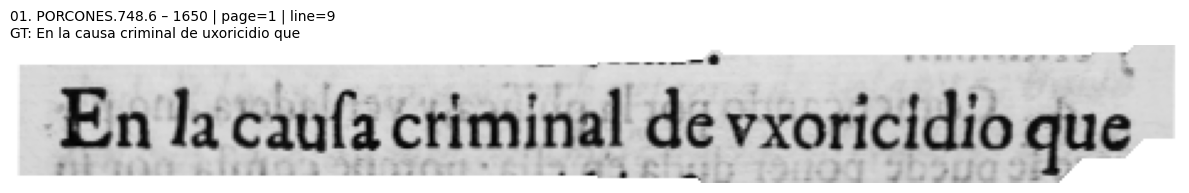

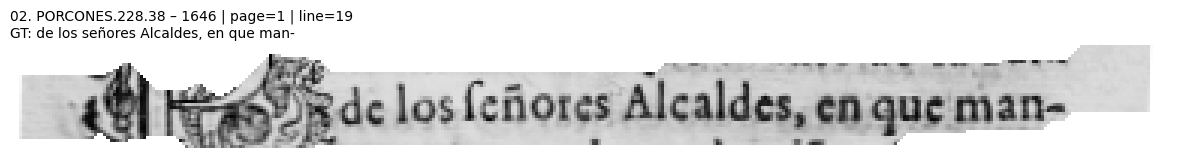

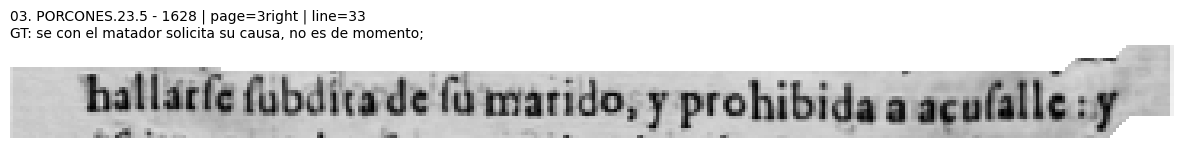

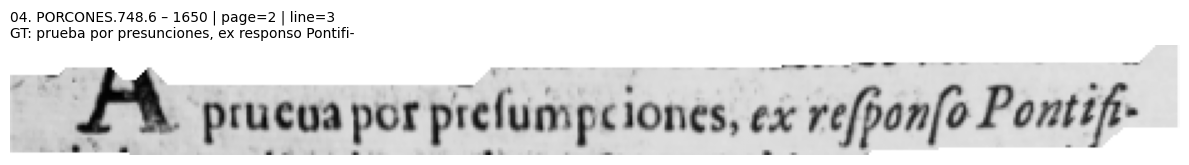

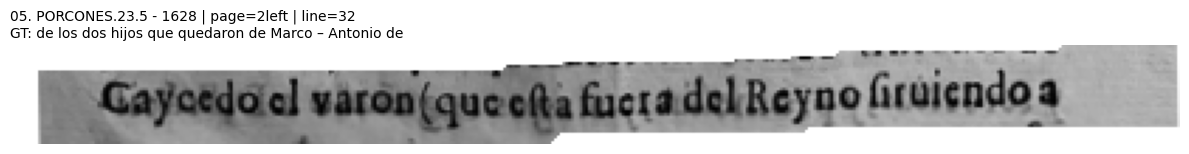

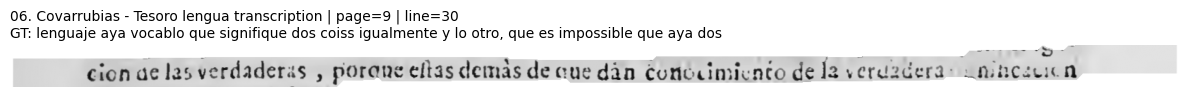

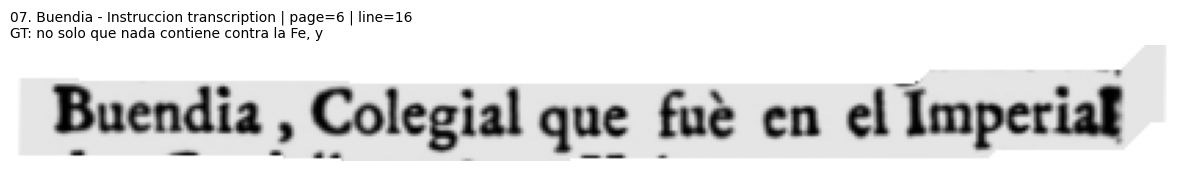

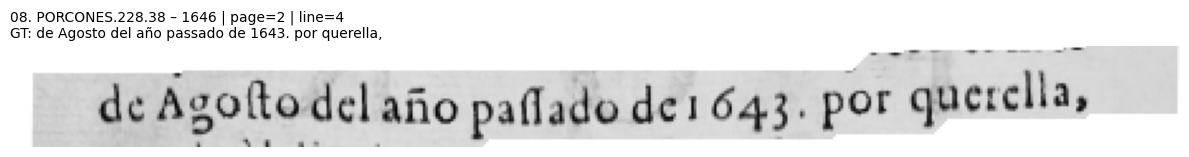

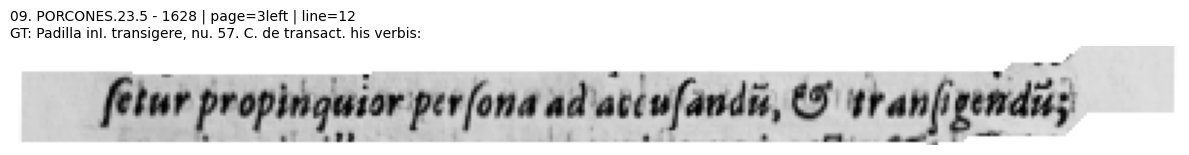

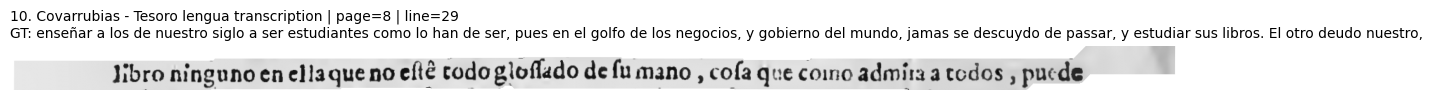

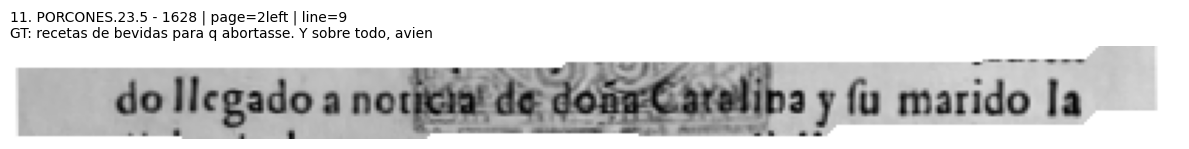

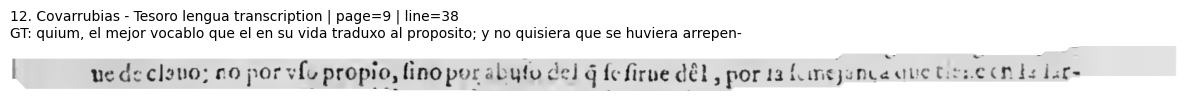

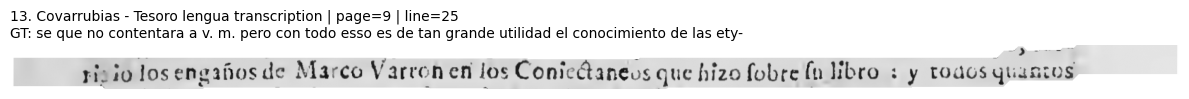

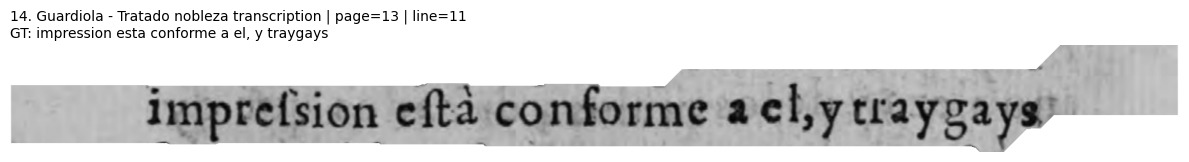

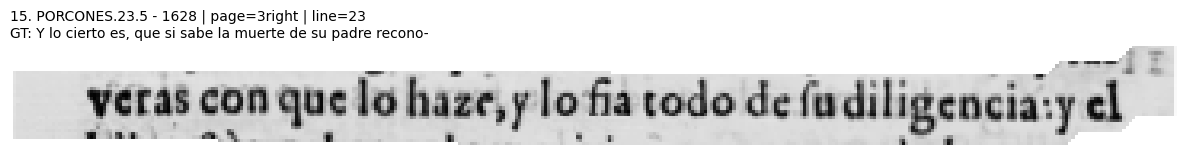

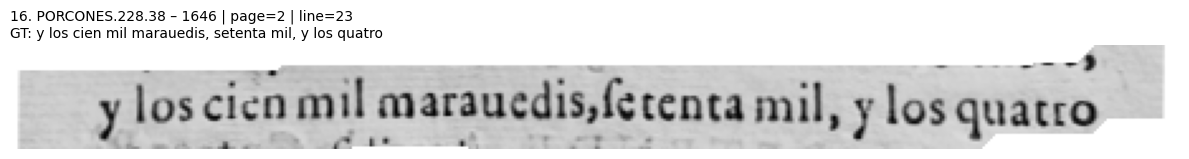

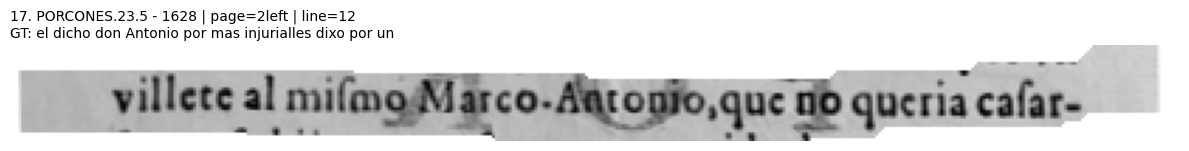

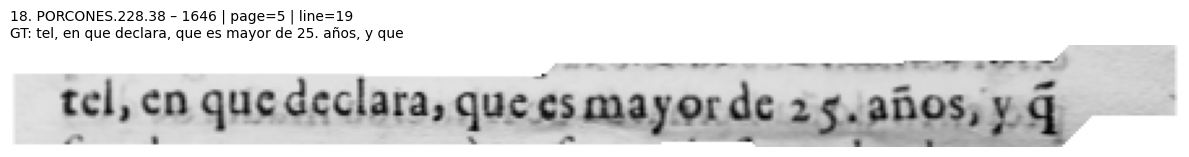

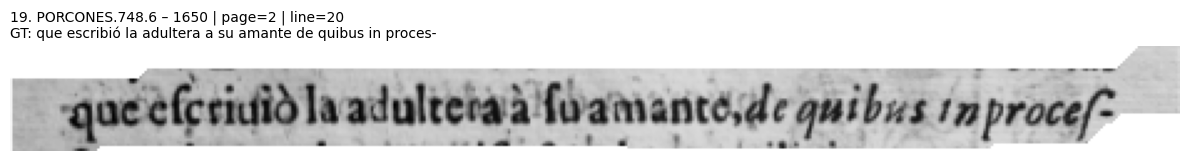

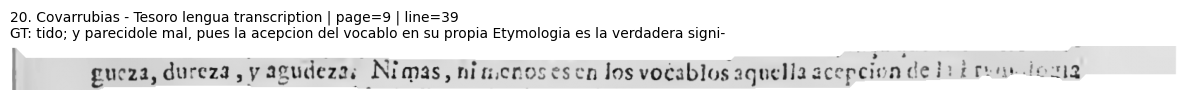

In [8]:
for i, row in sample_df.iterrows():
    img_path = Path(row["image_path"])

    fig, ax = plt.subplots(figsize=(12, 2.2))
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"{i+1:02d}. {row['source']} | page={row['page']} | line={row['line']}\n"
            f"GT: {row['ground_truth_text']}",
            fontsize=10,
            loc="left",
        )
        ax.axis("off")
    else:
        ax.text(0.01, 0.5, f"Missing image: {img_path}", va="center", ha="left")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import textwrap

def visualize_ground_truth(df, image_folder=None, num_samples=5):
    """
    Visualizes random images from the dataframe with their ground truth text.

    Parameters:
    - df: pandas DataFrame containing 'image_path' and 'ground_truth_text' columns.
    - image_folder: (Optional) Path to the local folder where images are stored.
                    If provided, the function looks for the image filename in this folder
                    instead of using the absolute path from the CSV.
    - num_samples: Number of random images to display.
    """

    # 1. Select random samples
    if len(df) > num_samples:
        samples = df.sample(n=num_samples)
    else:
        samples = df

    # 2. Setup the plot
    plt.figure(figsize=(15, 4 * len(samples)))

    for i, (_, row) in enumerate(samples.iterrows()):
        original_path = row['image_path']
        text = str(row['ground_truth_text'])

        # 3. Resolve Image Path
        if image_folder:
            # If a folder is provided, construct path using the filename
            # This is useful if you have all images in one directory
            filename = os.path.basename(original_path)
            img_path = os.path.join(image_folder, filename)

            # If not found, you might want to try preserving subdirectories manually,
            # but this defaults to looking in the root of image_folder.
        else:
            img_path = original_path

        # 4. Display Image and Text
        ax = plt.subplot(len(samples), 1, i + 1)

        if os.path.exists(img_path):
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f"Error opening image: {e}", ha='center', va='center')
                ax.axis('on')
        else:
            # Fallback if image is missing
            ax.text(0.5, 0.5, f"Image not found at:\n{img_path}",
                    ha='center', va='center', fontsize=12, color='red')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis('on')

        # Wrap text for better visibility
        wrapped_text = "\n".join(textwrap.wrap(text, width=80))
        ax.set_title(f"Ground Truth:\n{wrapped_text}", loc='left', fontsize=14, pad=10)

    plt.tight_layout()
    plt.show()

# --- Usage Example ---

# 1. Load your CSV
# df = pd.read_csv('line_alignment.csv')

# 2. Run the visualization
# Replace 'path/to/your/images' with the actual folder path on your machine
# visualize_ground_truth(df, image_folder='path/to/your/images', num_samples=3)

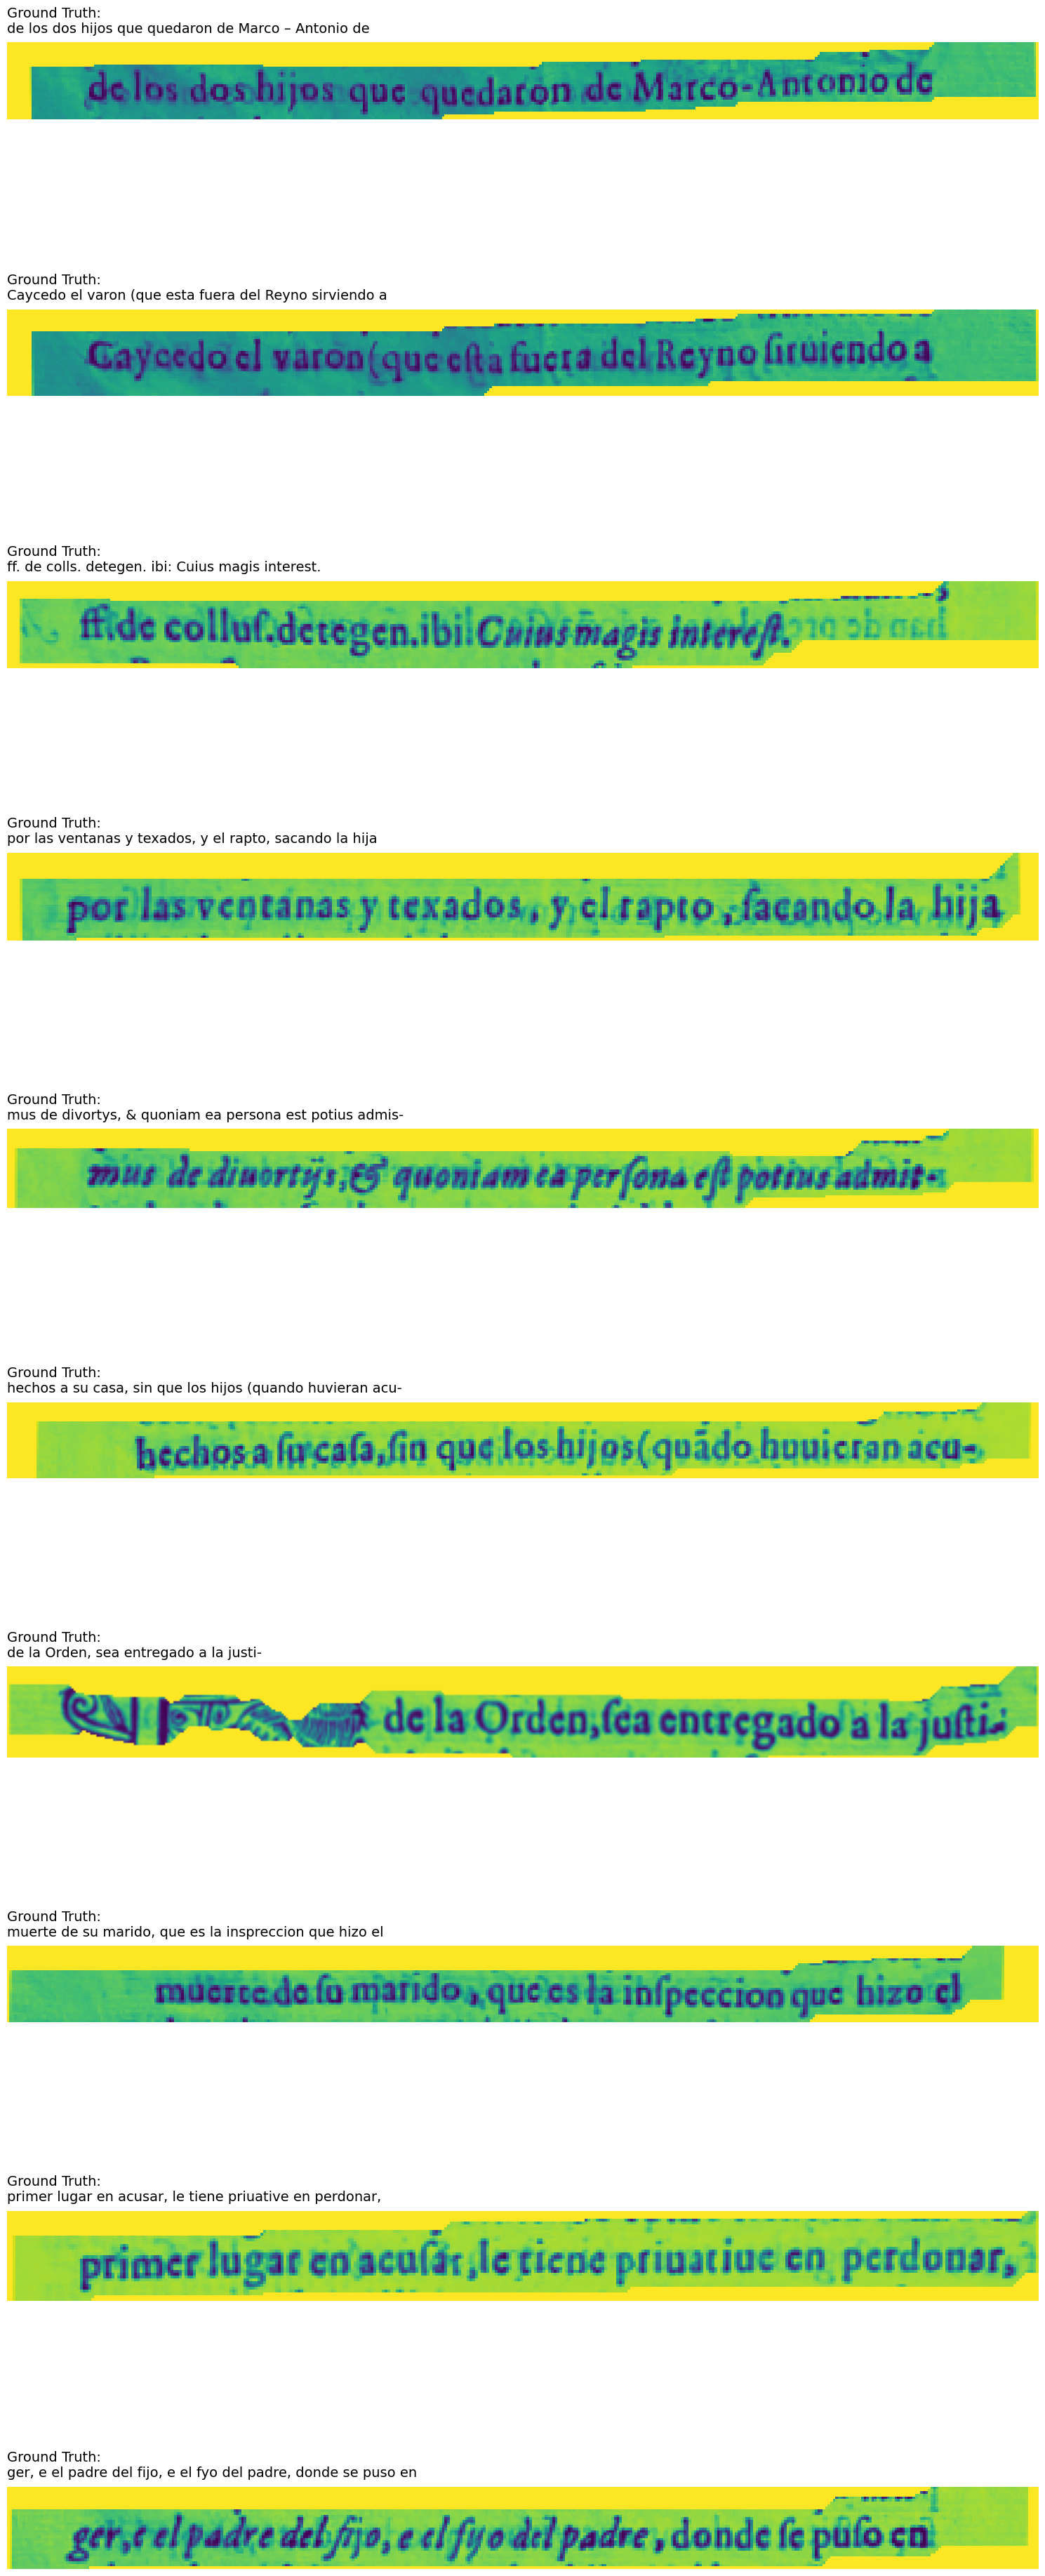

In [20]:
# 1. Load your CSV
df = pd.read_csv('/home/hemanth/Documents/RenAIssance/Test1/Data/line_alignment_by_source/source5__PORCONES_23_5_1628.csv')

# 2. Run the visualization
# Replace 'path/to/your/images' with the actual folder path on your machine
visualize_ground_truth(df, image_folder='/home/hemanth/Documents/RenAIssance/Test1/Data/line_crops/PORCONES.23.5 - 1628', num_samples=10)